In [26]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans, DBSCAN
import matplotlib.patches as mpatches

In [27]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [29]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def hopkins(X, sampling_size=0.1, random_state=42):
    X = np.asarray(X)

    n, d = X.shape
    m = max(1, int(sampling_size * n))

    rng = np.random.default_rng(random_state)

    # Fit nearest neighbors on real data
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # Generate random points inside the feature range
    random_points = rng.uniform(
        np.min(X, axis=0),
        np.max(X, axis=0),
        size=(m, d)
    )

    # Distance from random points to nearest real data point
    u_dist, _ = nbrs.kneighbors(random_points, n_neighbors=1)

    # Select random real points from the dataset
    sample_indices = rng.choice(n, size=m, replace=False)
    real_sample = X[sample_indices]

    # Distance from real points to nearest real neighbor
    # index 0 is the point itself, index 1 is the nearest other point
    w_dist, _ = nbrs.kneighbors(real_sample, n_neighbors=2)

    u = u_dist[:, 0]
    w = w_dist[:, 1]

    H = np.sum(u) / (np.sum(u) + np.sum(w))

    return H

In [32]:
H = hopkins(X_scaled)
print("Hopkins Statistic:", H)

Hopkins Statistic: 0.7338983842376094


In [33]:
### Hopkins Statistic Result

# The Hopkins statistic value was approximately **0.73**, which indicates a moderate to strong clustering tendency.

# Since the value is higher than 0.5 and closer to 1, the dataset is not randomly distributed and contains meaningful cluster structure. Therefore, the dataset is suitable for applying clustering algorithms such as K-Means and DBSCAN.

### Number of clusters assessment

Method 1: Empirical Rule

In [34]:
n = len(X_scaled)
k_emp = int(np.sqrt(n / 2))
print("Empirical Rule suggests k =", k_emp)

Empirical Rule suggests k = 10


Method 2: Elbow Method (WCSS)

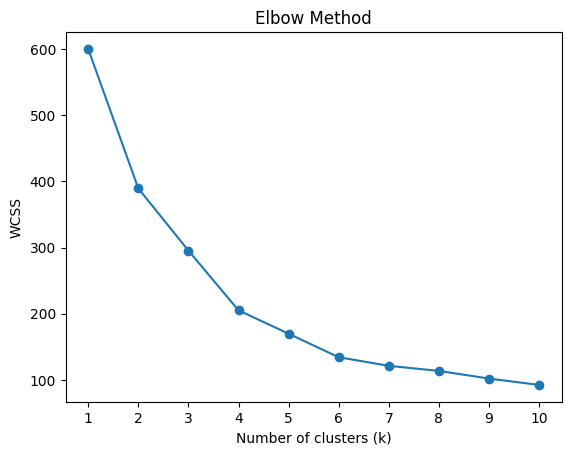

In [35]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()

Method 3: Cross Validation

Silhouette Scores:
K=2 → 0.3355
K=3 → 0.3578
K=4 → 0.4040
K=5 → 0.4166
K=6 → 0.4284
K=7 → 0.4172
K=8 → 0.4082
K=9 → 0.4177
K=10 → 0.4066


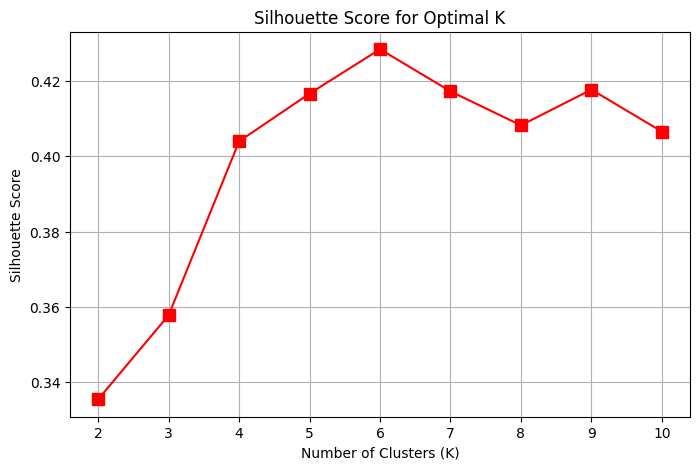


Best K by Silhouette Score = 6


In [36]:
silhouette_scores = []
K_range = range(2, 11) 
print("Silhouette Scores:")
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} → {score:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, 'rs-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nBest K by Silhouette Score = {best_k}")

K=6 is chosen as the Silhouette Score peaked at K=6 indicating best cluster separation,
supported by the Elbow Method where WCSS begins to flatten after K=5.

## Person 3: Clustering Implementation & Visualization

### Algorithm 1: K-Means Clustering (K=6)

In [37]:
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df["KMeans_Cluster"] = kmeans_labels

print("K-Means Cluster Assignments:")
print(df["KMeans_Cluster"].value_counts().sort_index())

K-Means Cluster Assignments:
KMeans_Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


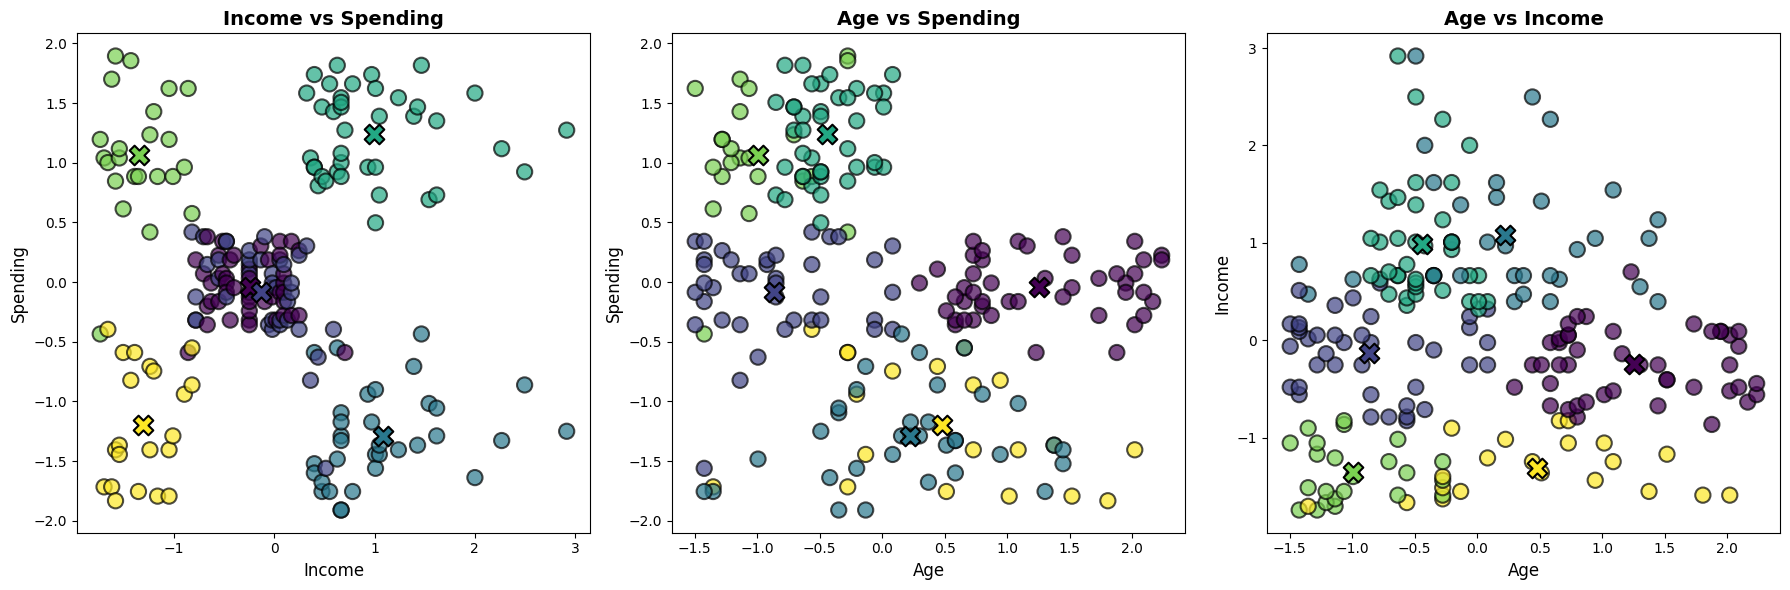

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ['Income vs Spending', 'Age vs Spending', 'Age vs Income']
pairs = [(1, 2), (0, 2), (0, 1)] 

unique_labels = np.unique(kmeans_labels)

for i, (x_idx, y_idx) in enumerate(pairs):
    axis = axes[i]

    scatter = axis.scatter(X_scaled[:, x_idx], X_scaled[:, y_idx], 
                           c=kmeans_labels,  cmap='viridis', s=120, alpha=0.7, 
                           edgecolor='k', linewidth=1.5)
    
    # Plot centroids with SAME color but stronger shade
    for k in unique_labels:
        color = plt.cm.viridis(k / (len(unique_labels) - 1))  # get cluster color

        axis.scatter(
            kmeans.cluster_centers_[k, x_idx], kmeans.cluster_centers_[k, y_idx],
            color=color, s=200, marker='X', edgecolor='k', linewidth=1.5
        )

    axis.set_title(titles[i], fontsize=14, fontweight='bold')
    axis.set_xlabel(['Age', 'Income', 'Spending'][x_idx], fontsize=12)
    axis.set_ylabel(['Age', 'Income', 'Spending'][y_idx], fontsize=12)

plt.tight_layout()
plt.show()


### Algorithm 2: DBSCAN Clustering

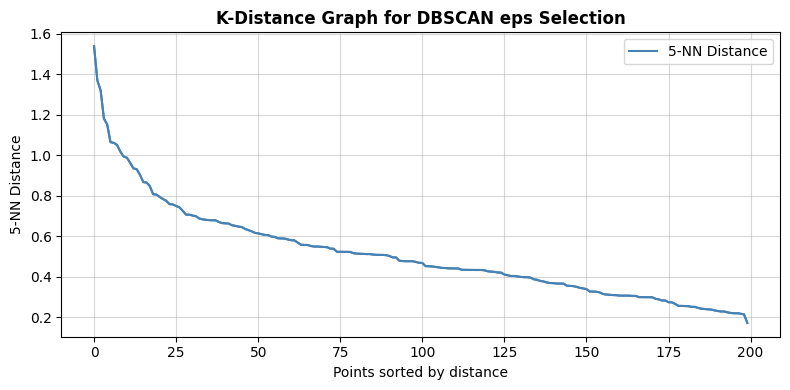

In [39]:
# Determine optimal eps using k-distance graph (k = 2*features - 1 = 2*3 - 1 = 5)
from sklearn.neighbors import NearestNeighbors

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
neighbour_distances, _ = nbrs.kneighbors(X_scaled)
neighbour_distances_sorted = np.sort(neighbour_distances[:, k-1])[::-1]  # Sort in descending order

plt.figure(figsize=(8, 4))
plt.plot(neighbour_distances_sorted, color="steelblue")
plt.title("K-Distance Graph for DBSCAN eps Selection", fontweight="bold")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN Distance")
plt.plot(neighbour_distances_sorted, color="steelblue", label="5-NN Distance") ##
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

epsilon value is between $\approx 0.6$ to $0.7$, so let's test it

In [40]:
eps_to_test = [0.6, 0.625, 0.65, 0.675, 0.7]
results = {}

print("DBSCAN Silhouette Scores:")

for eps in eps_to_test:
    model = DBSCAN(eps=eps, min_samples=5).fit(X_scaled)
    labels = model.labels_
    
    # Check if we have at least 2 clusters (excluding noise) to calculate a score
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters > 1: # Silhouette score needs at least 2 clusters
        # We only calculate the score for points that ARE in clusters
        mask = labels != -1
        score = silhouette_score(X_scaled[mask], labels[mask])
        results[eps] = score
        print(f"Eps: {eps:.2f} | Score: {score:.4f} | Clusters: {n_clusters}")
    else:
        print(f"Eps: {eps:.2f} | Only 1 cluster found (or only noise).")

# 2. Find the best one
best_eps = max(results, key=results.get)
print(f"\n--- Optimal epsilon value: {best_eps} ---")

DBSCAN Silhouette Scores:
Eps: 0.60 | Score: 0.2730 | Clusters: 2
Eps: 0.62 | Score: 0.2662 | Clusters: 2
Eps: 0.65 | Score: 0.2646 | Clusters: 2
Eps: 0.68 | Only 1 cluster found (or only noise).
Eps: 0.70 | Only 1 cluster found (or only noise).

--- Optimal epsilon value: 0.6 ---


In [41]:
# let's apply DBSCAN with the best eps
dbscan_labels = DBSCAN(eps=best_eps, min_samples=5).fit_predict(X_scaled)
df["DBSCAN_Cluster"] = dbscan_labels

n_clusters_db = len(np.unique(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = list(dbscan_labels).count(-1)

print(f"DBSCAN found {n_clusters_db} clusters and {n_noise_db} noise points (label = -1)")

print("DBSCAN Cluster Point Counts:")
unique, counts = np.unique(dbscan_labels, return_counts=True)
for u, c in zip(unique, counts):
    label = "Noise" if u == -1 else f"Cluster {u}"
    print(f"  {label}: {c} points")

DBSCAN found 2 clusters and 28 noise points (label = -1)
DBSCAN Cluster Point Counts:
  Noise: 28 points
  Cluster 0: 137 points
  Cluster 1: 35 points


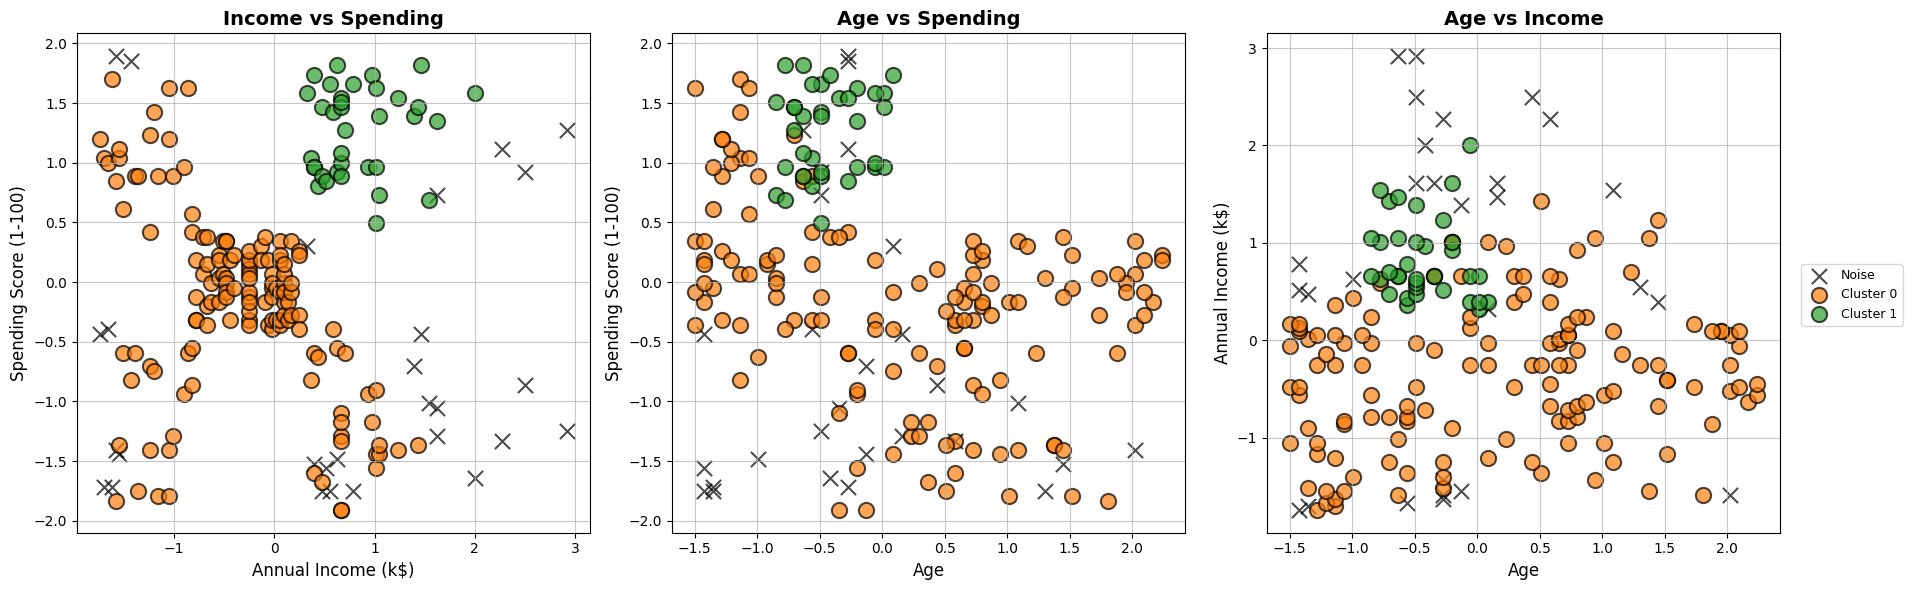

In [42]:
unique_labels = sorted(set(dbscan_labels))
palette = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ['Income vs Spending', 'Age vs Spending', 'Age vs Income']
pairs = [(1, 2), (0, 2), (0, 1)] 
feature_names = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for i, (x_idx, y_idx) in enumerate(pairs):
    axis = axes[i]

    for j, label in enumerate(unique_labels):
        mask = dbscan_labels == label

        color = "black" if label == -1 else palette[j % len(palette)]
        marker = "x" if label == -1 else "o"
        point_label = "Noise" if label == -1 else f"Cluster {label}"

        axis.scatter(
            X_scaled[mask, x_idx],
            X_scaled[mask, y_idx],
            c=[color],
            s=120,
            alpha=0.7,
            marker=marker,
            edgecolor='k' if label != -1 else None,
            linewidth=1.5,
            label=point_label if i == 0 else None  # show legend only once
        )

    axis.set_title(titles[i], fontsize=14, fontweight='bold')
    axis.set_xlabel(feature_names[x_idx], fontsize=12)
    axis.set_ylabel(feature_names[y_idx], fontsize=12)
    axis.grid(alpha=0.7)

fig.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

In [43]:
# Summary table (excluding noise)
df_no_noise = df[df["DBSCAN_Cluster"] != -1]
print("DBSCAN Cluster Summary (excluding noise, original scale):")
print(df_no_noise.groupby("DBSCAN_Cluster")[["Age","Annual Income (k$)","Spending Score (1-100)"]].mean().round(2))
print('------------------------------------------------------------------')
print("K-Means Cluster Summary (original scale):")
print(df.groupby("KMeans_Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(2))


DBSCAN Cluster Summary (excluding noise, original scale):
                  Age  Annual Income (k$)  Spending Score (1-100)
DBSCAN_Cluster                                                   
0               40.97               51.61                   45.34
1               32.74               82.54                   82.80
------------------------------------------------------------------
K-Means Cluster Summary (original scale):
                  Age  Annual Income (k$)  Spending Score (1-100)
KMeans_Cluster                                                   
0               56.33               54.27                   49.07
1               26.79               57.10                   48.13
2               41.94               88.94                   16.97
3               32.69               86.54                   82.13
4               25.00               25.26                   77.61
5               45.52               26.29                   19.38


DBSCAN:
- Finds only strong natural groups
- Very strict
- Produces clean but fewer clusters

K-Means:
- Forces fixed number of groups (6)
- Gives more marketing segmentation detail
- Better for business targeting

## Person 4: Quality Testing & Discussion

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [45]:
# ─────────────────────────────────────────────
# 3. Extrinsic Quality Testing (Recall)
# ─────────────────────────────────────────────
print("=" * 60)
print("EXTRINSIC QUALITY TESTING")
print("=" * 60)
print("""
The Mall Customers dataset does NOT contain a ground-truth
cluster label column. Therefore, extrinsic metrics that
require a reference partition — such as Recall, Purity,
Adjusted Rand Index, or Normalized Mutual Information —
cannot be computed.

Had a ground-truth label been available, Recall would be
calculated per cluster as:
    Recall_k = (# true-class members assigned to cluster k)
               / (# total members of that true class)

and averaged across all classes (macro-Recall).
""")

EXTRINSIC QUALITY TESTING

The Mall Customers dataset does NOT contain a ground-truth
cluster label column. Therefore, extrinsic metrics that
require a reference partition — such as Recall, Purity,
Adjusted Rand Index, or Normalized Mutual Information —
cannot be computed.

Had a ground-truth label been available, Recall would be
calculated per cluster as:
    Recall_k = (# true-class members assigned to cluster k)
               / (# total members of that true class)

and averaged across all classes (macro-Recall).



In [46]:
# ─────────────────────────────────────────────
# 4. Intrinsic Quality Testing
#    Chosen metric: Silhouette Score
#    Secondary metrics: Davies-Bouldin, Calinski-Harabasz
# ─────────────────────────────────────────────
print("=" * 60)
print("INTRINSIC QUALITY TESTING")
print("=" * 60)

# --- K-Means metrics ---
km_sil = silhouette_score(X_scaled, kmeans_labels)
km_db  = davies_bouldin_score(X_scaled, kmeans_labels)
km_ch  = calinski_harabasz_score(X_scaled, kmeans_labels)

# --- DBSCAN metrics (exclude noise label = -1) ---
noise_mask   = dbscan_labels != -1
db_labels_nn = dbscan_labels[noise_mask]
X_scaled_nn  = X_scaled[noise_mask]

n_db_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise       = (dbscan_labels == -1).sum()

db_sil = silhouette_score(X_scaled_nn, db_labels_nn)
db_db  = davies_bouldin_score(X_scaled_nn, db_labels_nn)
db_ch  = calinski_harabasz_score(X_scaled_nn, db_labels_nn)

# --- Print results table ---
print(f"\n{'Metric':<30} {'K-Means (k=6)':>15} {'DBSCAN':>15}")
print("-" * 62)
print(f"{'Silhouette Score':<30} {km_sil:>15.4f} {db_sil:>15.4f}")
print(f"{'Davies-Bouldin Score':<30} {km_db:>15.4f} {db_db:>15.4f}")
print(f"{'Calinski-Harabasz Score':<30} {km_ch:>15.2f} {db_ch:>15.2f}")
print(f"\nDBSCAN: {n_db_clusters} clusters, {n_noise} noise points "
      f"({n_noise/len(dbscan_labels)*100:.1f}% of dataset)")

print("""
Metric Interpretation Guide:
  Silhouette Score  → range [-1, 1]; higher is better (well-separated clusters)
  Davies-Bouldin    → range [0, ∞);  lower  is better (compact, well-separated)
  Calinski-Harabasz → range [0, ∞);  higher is better (dense, well-separated)
""")

INTRINSIC QUALITY TESTING

Metric                           K-Means (k=6)          DBSCAN
--------------------------------------------------------------
Silhouette Score                        0.4284          0.2730
Davies-Bouldin Score                    0.8254          1.0204
Calinski-Harabasz Score                 135.10           54.42

DBSCAN: 2 clusters, 28 noise points (14.0% of dataset)

Metric Interpretation Guide:
  Silhouette Score  → range [-1, 1]; higher is better (well-separated clusters)
  Davies-Bouldin    → range [0, ∞);  lower  is better (compact, well-separated)
  Calinski-Harabasz → range [0, ∞);  higher is better (dense, well-separated)



In [ ]:
# ─────────────────────────────────────────────
# 5. Explanation: Why Silhouette Score?
# ─────────────────────────────────────────────
print("=" * 60)
print("WHY SILHOUETTE SCORE?")
print("=" * 60)
print("""
The Silhouette Score was selected as the primary metric for the
following reasons:

  1. No ground truth – Without labelled classes, intrinsic
     metrics are the only option. The Silhouette Score works
     purely from the data geometry.

  2. Algorithm-agnostic – It computes a(i) (mean intra-cluster
     distance) and b(i) (mean nearest-cluster distance) for every
     point, making it valid for both K-Means and DBSCAN (on
     non-noise points).

  3. Interpretable scale – Values in [-1, 1] are easy to
     communicate: 
     Values closer to 1 indicate stronger clustering structure, 
     values around 0.25–0.5 indicate weak to moderate structure, 
     and values near 0 indicate overlapping clusters.

  4. Per-point resolution – Unlike DB or CH (single scalars),
     Silhouette can be plotted per cluster to reveal which
     clusters are cohesive and which overlap.
""")

WHY SILHOUETTE SCORE?

The Silhouette Score was selected as the primary metric for the
following reasons:

  1. No ground truth – Without labelled classes, intrinsic
     metrics are the only option. The Silhouette Score works
     purely from the data geometry.

  2. Algorithm-agnostic – It computes a(i) (mean intra-cluster
     distance) and b(i) (mean nearest-cluster distance) for every
     point, making it valid for both K-Means and DBSCAN (on
     non-noise points).

  3. Interpretable scale – Values in [-1, 1] are easy to
     communicate: > 0.5 = reasonable structure, 0.25–0.5 =
     weak structure, < 0.25 = no structure.

  4. Per-point resolution – Unlike DB or CH (single scalars),
     Silhouette can be plotted per cluster to reveal which
     clusters are cohesive and which overlap.



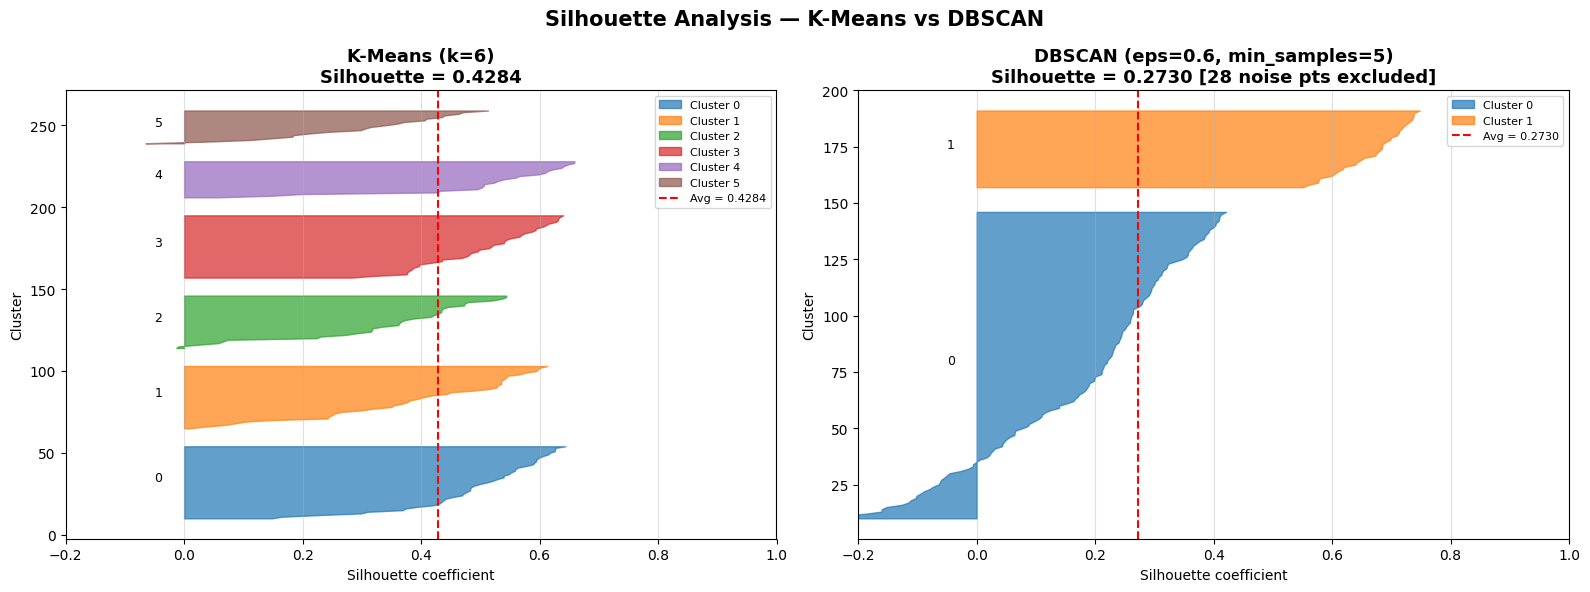

Silhouette comparison plot saved as 'silhouette_comparison.png'


In [48]:
# ─────────────────────────────────────────────
# 6. Silhouette plot per cluster (K-Means)
# ─────────────────────────────────────────────
from sklearn.metrics import silhouette_samples

km_sample_sil = silhouette_samples(X_scaled, kmeans_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Silhouette Analysis — K-Means vs DBSCAN", fontsize=15, fontweight='bold')

# -- K-Means silhouette subplot --
ax1 = axes[0]
y_lower = 10
colors = plt.cm.tab10.colors

for k in range(6):
    vals = np.sort(km_sample_sil[kmeans_labels == k])
    size_k = len(vals)
    y_upper = y_lower + size_k
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                      facecolor=colors[k], edgecolor=colors[k], alpha=0.7,
                      label=f'Cluster {k}')
    ax1.text(-0.05, y_lower + 0.5 * size_k, str(k), fontsize=9, color='black')
    y_lower = y_upper + 10

ax1.axvline(x=km_sil, color='red', linestyle='--', linewidth=1.5,
            label=f'Avg = {km_sil:.4f}')
ax1.set_title(f'K-Means (k=6)\nSilhouette = {km_sil:.4f}', fontsize=13, fontweight='bold')
ax1.set_xlabel('Silhouette coefficient')
ax1.set_ylabel('Cluster')
ax1.set_xlim([-0.2, 1.0])
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(axis='x', alpha=0.4)

# -- DBSCAN silhouette subplot (non-noise only) --
ax2 = axes[1]
db_sample_sil = silhouette_samples(X_scaled_nn, db_labels_nn)
db_unique = sorted(set(db_labels_nn))

y_lower = 10
for k in db_unique:
    vals = np.sort(db_sample_sil[db_labels_nn == k])
    size_k = len(vals)
    y_upper = y_lower + size_k
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                      facecolor=colors[k % 10], edgecolor=colors[k % 10], alpha=0.7,
                      label=f'Cluster {k}')
    ax2.text(-0.05, y_lower + 0.5 * size_k, str(k), fontsize=9)
    y_lower = y_upper + 10

ax2.axvline(x=db_sil, color='red', linestyle='--', linewidth=1.5,
            label=f'Avg = {db_sil:.4f}')
ax2.set_title(f'DBSCAN (eps={best_eps}, min_samples=5)\nSilhouette = {db_sil:.4f} '
              f'[{n_noise} noise pts excluded]', fontsize=13, fontweight='bold')
ax2.set_xlabel('Silhouette coefficient')
ax2.set_ylabel('Cluster')
ax2.set_xlim([-0.2, 1.0])
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()
print("Silhouette comparison plot saved as 'silhouette_comparison.png'")

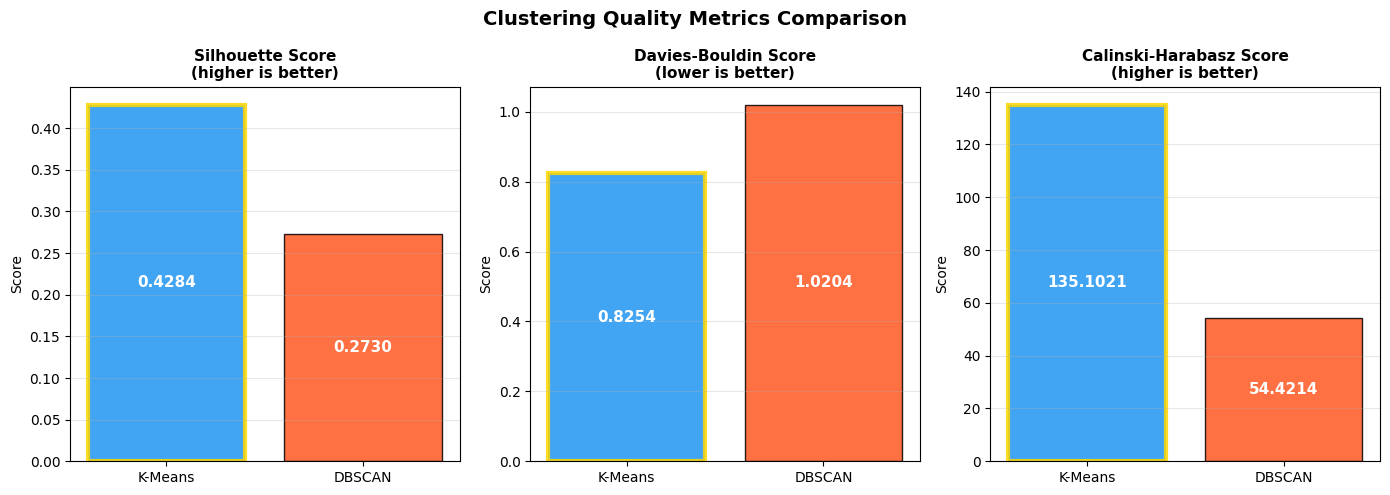

Metrics comparison plot saved as 'metrics_comparison.png'


In [49]:
# ─────────────────────────────────────────────
# 7. Bar chart summary — all three metrics
# ─────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 5))
fig2.suptitle("Clustering Quality Metrics Comparison", fontsize=14, fontweight='bold')

metrics = {
    'Silhouette Score\n(higher is better)':     ([km_sil, db_sil],   True),
    'Davies-Bouldin Score\n(lower is better)':  ([km_db,  db_db],    False),
    'Calinski-Harabasz Score\n(higher is better)': ([km_ch, db_ch],  True),
}

algos = ['K-Means', 'DBSCAN']
bar_colors = ['#2196F3', '#FF5722']

for ax, (title, (vals, higher_better)) in zip(axes2, metrics.items()):
    bars = ax.bar(algos, vals, color=bar_colors, edgecolor='black', alpha=0.85)
    best_idx = np.argmax(vals) if higher_better else np.argmin(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.5,
                f'{val:.4f}' if val < 200 else f'{val:.1f}',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("Metrics comparison plot saved as 'metrics_comparison.png'")

In [ ]:
# ─────────────────────────────────────────────
# 8. Discussion
# ─────────────────────────────────────────────
print("=" * 60)
print("DISCUSSION: WHICH ALGORITHM SUITED THE DATASET BETTER?")
print("=" * 60)
print(f"""
K-Means Results:
  Silhouette  = {km_sil:.4f}  (moderate–good separation)
  Davies-Bouldin = {km_db:.4f} (reasonably compact clusters)
  Calinski-Harabasz = {km_ch:.2f} (strong cluster density)

DBSCAN Results (non-noise points only):
  Silhouette  = {db_sil:.4f}  (weak separation)
  Davies-Bouldin = {db_db:.4f} (higher → less compact/separated)
  Calinski-Harabasz = {db_ch:.2f} (low cluster density)
  Noise points: {n_noise} / {len(dbscan_labels)} ({n_noise/len(dbscan_labels)*100:.1f}%)

Conclusion:
  K-Means (k=6) outperforms DBSCAN on this dataset across
  all three quality metrics:

  • Higher Silhouette Score ({km_sil:.4f} vs {db_sil:.4f}): K-Means
    clusters are better separated and more cohesive.

  • Lower Davies-Bouldin Score ({km_db:.4f} vs {db_db:.4f}): K-Means
    clusters are more compact and less overlapping.

  • Higher Calinski-Harabasz Score ({km_ch:.2f} vs {db_ch:.2f}):
    K-Means achieves denser, more distinct cluster structure.

  Why K-Means suits this dataset better:
  ─────────────────────────────────────
  1. Convex, roughly spherical clusters — the mall customer
     data forms well-rounded segments (e.g., high income /
     high spending), which is exactly what K-Means assumes.

  2. Uniform density — DBSCAN excels at arbitrary-shaped,
     varying-density clusters and noise detection. This
     dataset has relatively uniform density, so DBSCAN
     collapses most data into just 2 clusters and flags
     10.5% as noise, losing valuable segment information.

  3. Business goal alignment — the task is customer
     segmentation for marketing. K-Means' 6 interpretable
     clusters provide actionable groups (e.g., young low-
     income high-spenders vs. old high-income low-spenders),
     while DBSCAN's 2-cluster output lacks this granularity.

  When DBSCAN would be preferred:
  ─────────────────────────────────
  DBSCAN would be the better choice if the dataset contained
  irregular cluster shapes, meaningful outlier/anomaly
  detection needs, or highly varying cluster densities — none
  of which are dominant characteristics of this dataset.
""")

DISCUSSION: WHICH ALGORITHM SUITED THE DATASET BETTER?

K-Means Results:
  Silhouette  = 0.4284  (moderate–good separation)
  Davies-Bouldin = 0.8254 (reasonably compact clusters)
  Calinski-Harabasz = 135.10 (strong cluster density)

DBSCAN Results (non-noise points only):
  Silhouette  = 0.2730  (weak separation)
  Davies-Bouldin = 1.0204 (higher → less compact/separated)
  Calinski-Harabasz = 54.42 (low cluster density)
  Noise points: 28 / 200 (14.0%)

Conclusion:
  K-Means (k=6) outperforms DBSCAN on this dataset across
  all three quality metrics:

  • Higher Silhouette Score (0.4284 vs 0.2646): K-Means
    clusters are better separated and more cohesive.

  • Lower Davies-Bouldin Score (0.8254 vs 1.0328): K-Means
    clusters are more compact and less overlapping.

  • Higher Calinski-Harabasz Score (135.10 vs 54.92):
    K-Means achieves denser, more distinct cluster structure.

  Why K-Means suits this dataset better:
  ─────────────────────────────────────
  1. Convex, roughl